In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [112]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [114]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [115]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [116]:
cols = ['Glucose', 'BloodPressure', 'BMI']

df[cols] = df[cols].replace(0, np.nan)

df.fillna(df.mean(), inplace=True)

In [117]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

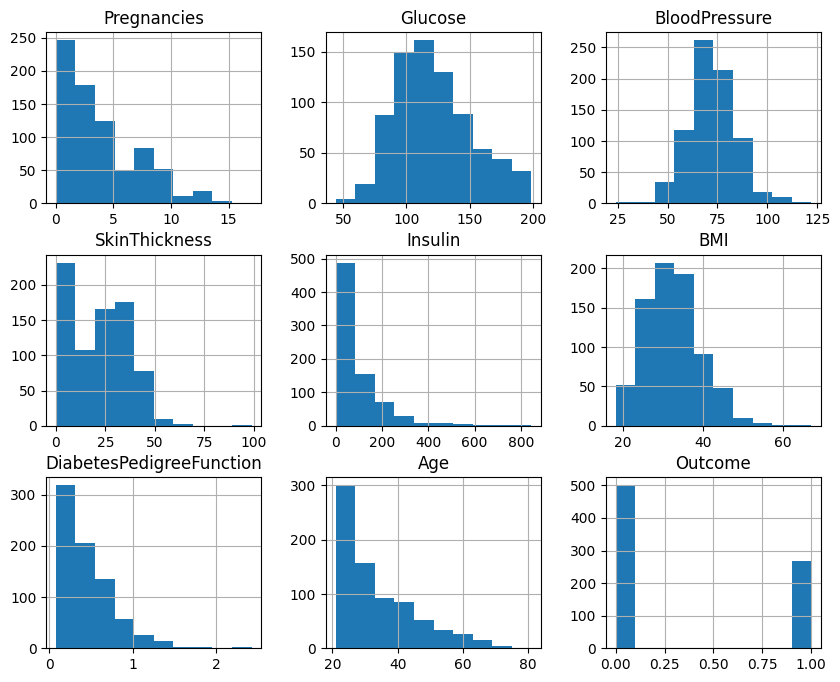

In [118]:
df.hist(figsize=(10,8))
plt.show()

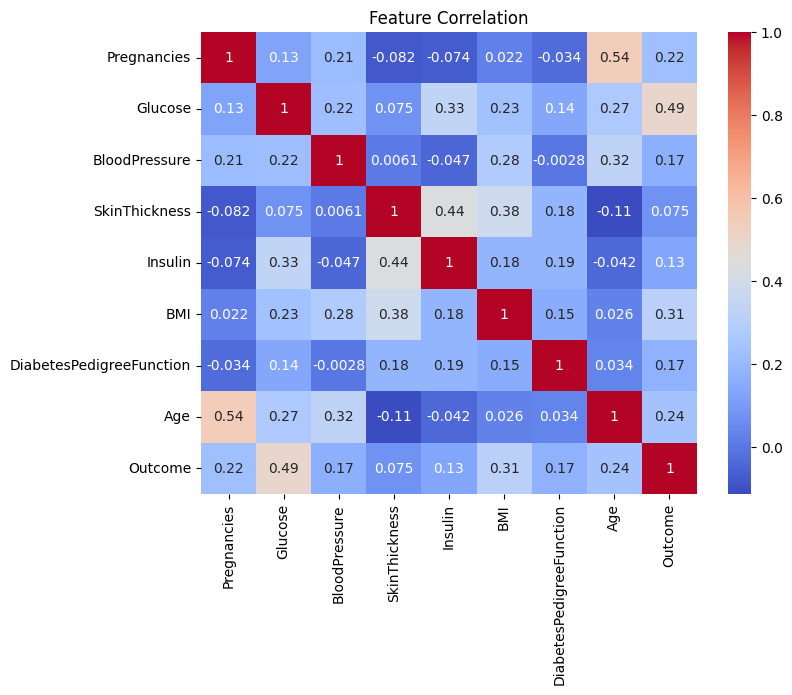

In [119]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [120]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [122]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

acc1 = model1.score(X_test, y_test)
print("Logistic Regression Accuracy:", acc1)

Logistic Regression Accuracy: 0.7662337662337663


In [123]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier()
model2.fit(X_train, y_train)

acc2 = model2.score(X_test, y_test)
print("Decision Tree Accuracy:", acc2)

Decision Tree Accuracy: 0.7142857142857143


In [124]:
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier()
model3.fit(X_train, y_train)

acc3 = model3.score(X_test, y_test)
print("Random Forest Accuracy:", acc3)

Random Forest Accuracy: 0.7467532467532467


In [125]:
print("Logistic:", acc1)
print("Decision Tree:", acc2)
print("Random Forest:", acc3)

Logistic: 0.7662337662337663
Decision Tree: 0.7142857142857143
Random Forest: 0.7467532467532467


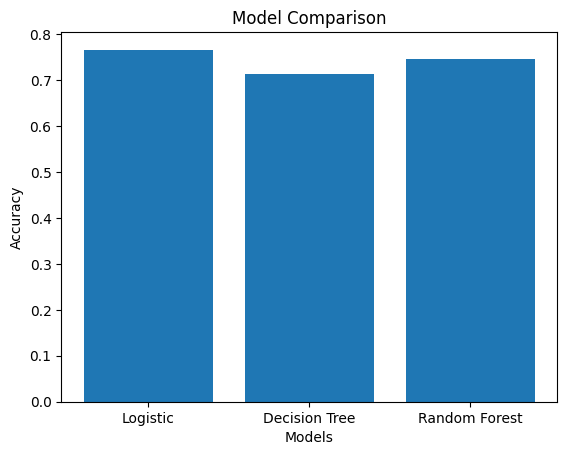

In [126]:
models = ["Logistic", "Decision Tree", "Random Forest"]
accuracies = [acc1, acc2, acc3]

plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [127]:
from sklearn.metrics import confusion_matrix

y_pred = model3.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[76 23]
 [16 39]]


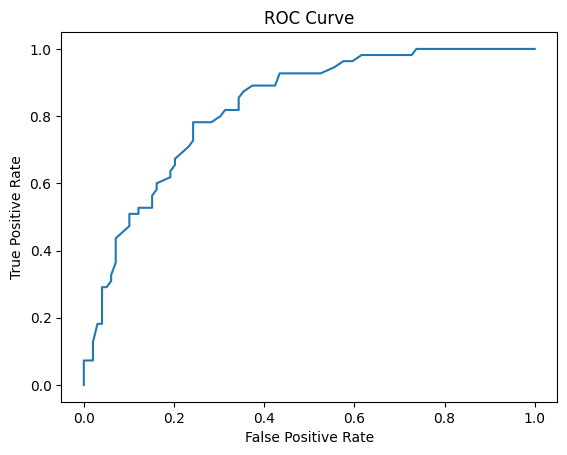

In [128]:
from sklearn.metrics import roc_curve, auc

probs = model3.predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test, probs[:,1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [129]:
def risk_level(prob):
    if prob < 0.3:
        return "Low"
    elif prob < 0.7:
        return "Medium"
    else:
        return "High"

In [130]:
for i in range(9):
    p = probs[i][1]
    print(f"Patient {i}: {p:.2f} → {risk_level(p)} risk")

Patient 0: 0.45 → Medium risk
Patient 1: 0.27 → Low risk
Patient 2: 0.15 → Low risk
Patient 3: 0.16 → Low risk
Patient 4: 0.51 → Medium risk
Patient 5: 0.68 → Medium risk
Patient 6: 0.05 → Low risk
Patient 7: 0.68 → Medium risk
Patient 8: 0.60 → Medium risk


In [131]:
import sys
!{sys.executable} -m pip install shap


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [132]:
import shap

In [133]:
explainer = shap.TreeExplainer(model3)
shap_values = explainer.shap_values(X_test)

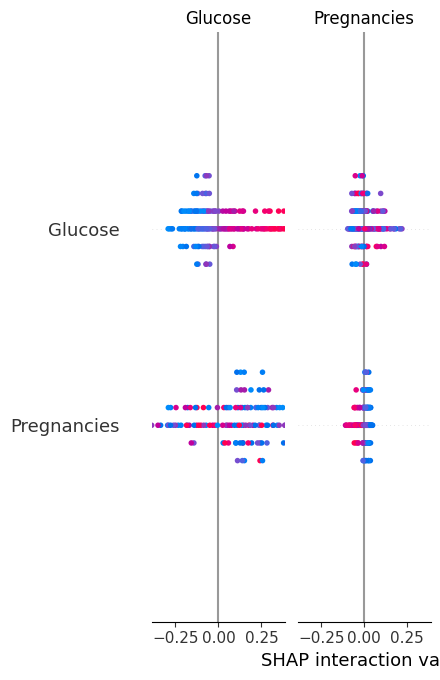

In [134]:
shap.summary_plot(shap_values, X_test)

In [135]:
sample = X_test.iloc[4]

explainer = shap.TreeExplainer(model3)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    sample_shap = shap_values[1][0]   # class 1
else:
    sample_shap = shap_values[0]

import numpy as np
sample_shap = np.array(sample_shap).flatten()

features = X_test.columns

In [136]:
for feature, value in zip(features, sample_shap):
    print(f"{feature}: {value:.4f}")

Pregnancies: -0.0070
Glucose: 0.0070
BloodPressure: 0.1564
SkinThickness: -0.1564
Insulin: 0.0179
BMI: -0.0179
DiabetesPedigreeFunction: 0.0049
Age: -0.0049


In [137]:
import numpy as np

sample = X_test.iloc[0]

explainer = shap.TreeExplainer(model3)
shap_values = explainer.shap_values(X_test)

# Handle classification output
if isinstance(shap_values, list):
    sample_shap = shap_values[1][0]
else:
    sample_shap = shap_values[0]

# Fix shape
sample_shap = np.array(sample_shap)

if len(sample_shap.shape) > 1:
    sample_shap = sample_shap[0]

features = X_test.columns

In [138]:
# Make lengths safe
min_len = min(len(features), len(sample_shap))

sample_shap = sample_shap[:min_len]
features = features[:min_len]

# Top 5 features
indices = np.argsort(np.abs(sample_shap))[::-1][:5]

print("\nExplanation (Top Factors):")

for i in indices:
    feature = features[i]
    value = sample_shap[i]
    
    if value > 0:
        print(f"{feature} increases risk")
    else:
        print(f"{feature} decreases risk")


Explanation (Top Factors):
Glucose increases risk
Pregnancies decreases risk
